# Lab 1 Curve fitting


### Experiment Part One

Column names in CSV: ['trial', 'starting_angle', 'time', 'length(m)', 'oscillations']
PENDULUM DATA ANALYSIS - Part 1: Theoretical Comparison

Pendulum Length: L = 0.6824 m

Raw Data:
   trial  starting_angle  time  length(m)  oscillations
0      1              10  16.4     0.6824            10
1      2              20  16.6     0.6824            10
2      3              25  16.5     0.6824            10
3      4              30  16.8     0.6824            10
4      5              40  17.1     0.6824            10
5      6              50  17.2     0.6824            10
6      7              55  17.5     0.6824            10
7      8              60  17.6     0.6824            10
8      9              70  18.4     0.6824            10
9     10              80  18.9     0.6824            10



COMPUTING THEORETICAL PREDICTIONS:

Running Velocity Verlet simulations...
  Simulating θ₀ = 10°... T = 1.6603 s
  Simulating θ₀ = 20°... T = 1.6699 s
  Simulating θ₀ = 25°... T = 1.6771 s
  Simula

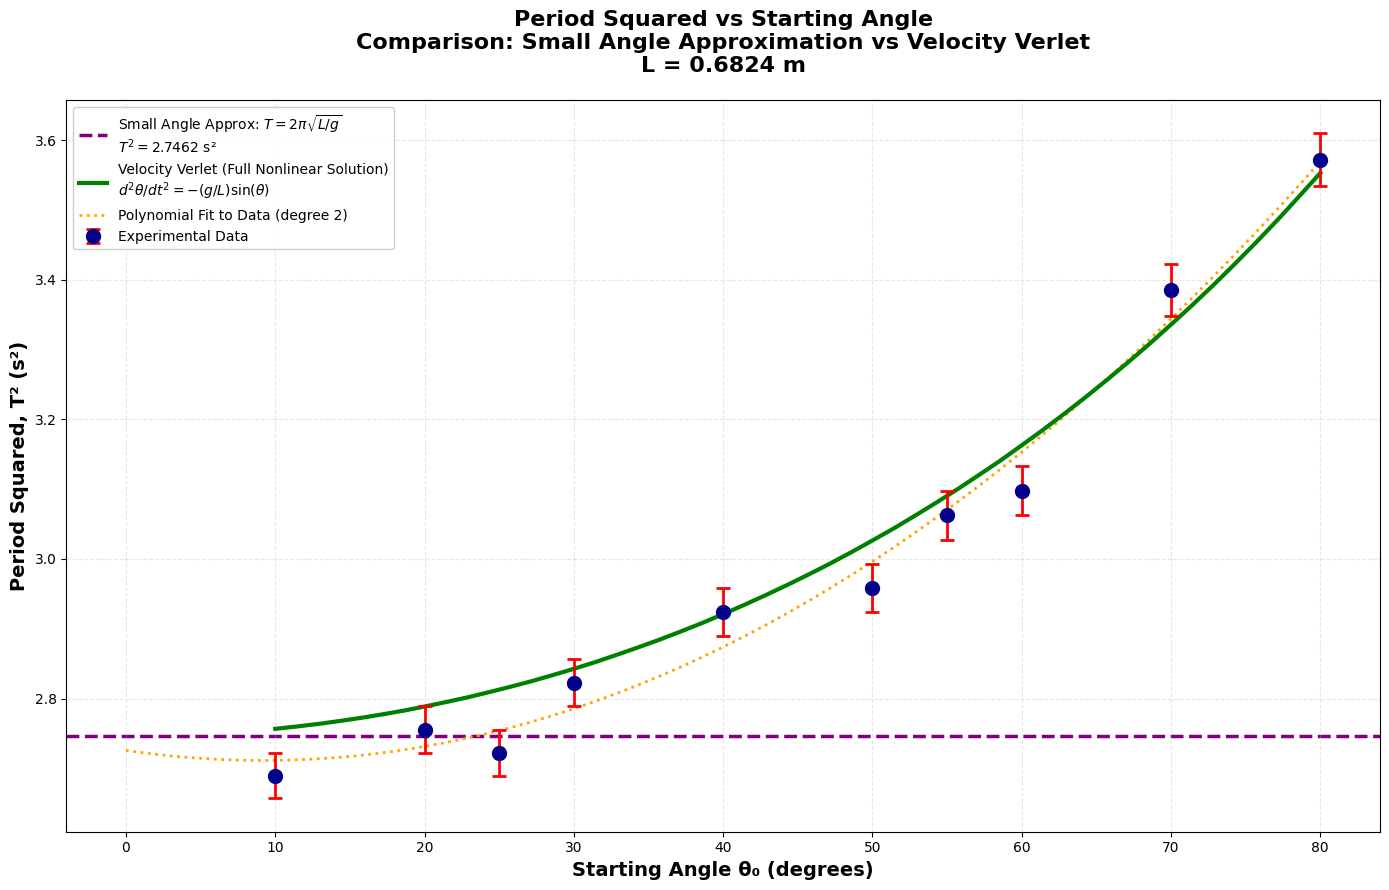


STATISTICAL ANALYSIS:

RMS Error (Small Angle Approx): 0.1070 s
RMS Error (Velocity Verlet):    0.0151 s
Improvement factor: 7.08x

Mean Absolute Percentage Error:
  Small Angle: 4.32%
  Velocity Verlet: 0.75%

CONCLUSIONS:
• Small angle approximation works well up to ~50°
• At 80°, small angle error is 12.3%
• Velocity Verlet provides 7.1x better accuracy
• Full nonlinear solution is REQUIRED for large amplitude oscillations

Enhanced data saved to: LAB_1_Part_1_With_Theory.csv


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

# ============================================================================
# VELOCITY VERLET INTEGRATION FOR NONLINEAR PENDULUM (FIXED)
# ============================================================================

def velocity_verlet_pendulum(theta0_deg, L, g, num_periods=10, dt=0.001):
    """
    Solve nonlinear pendulum equation using Velocity Verlet algorithm.
    
    Equation: d²θ/dt² = -(g/L)sin(θ)
    
    Parameters:
    -----------
    theta0_deg : float - Initial angle in degrees
    L : float - Pendulum length in meters
    g : float - Gravitational acceleration (m/s²)
    num_periods : int - Number of periods to simulate
    dt : float - Time step in seconds
    
    Returns:
    --------
    t : array - Time values
    theta : array - Angle values (radians)
    period : float - Measured period
    """
    # Convert initial angle to radians
    theta0 = np.deg2rad(theta0_deg)
    
    # Initial conditions
    theta = theta0  # Initial angle
    omega = 0.0     # Initial angular velocity (released from rest)
    
    # Arrays to store results
    theta_history = [theta]
    omega_history = [omega]
    t_history = [0.0]
    
    # Estimate total time needed (use small angle approximation × 2 for safety)
    T_approx = 2 * np.pi * np.sqrt(L / g)
    total_time = num_periods * T_approx * 2
    
    # Time stepping
    t = 0.0
    zero_crossings = []
    last_theta = theta
    crossing_direction = []  # Track if crossing is positive->negative or negative->positive
    
    while t < total_time:
        # Acceleration at current position
        alpha = -(g / L) * np.sin(theta)
        
        # Velocity Verlet update
        theta_new = theta + omega * dt + 0.5 * alpha * dt**2
        alpha_new = -(g / L) * np.sin(theta_new)
        omega_new = omega + 0.5 * (alpha + alpha_new) * dt
        
        # Detect BOTH zero crossings (positive->negative AND negative->positive)
        if last_theta > 0 and theta_new <= 0:
            zero_crossings.append(t)
            crossing_direction.append('down')
        elif last_theta < 0 and theta_new >= 0:
            zero_crossings.append(t)
            crossing_direction.append('up')
        
        # Update
        theta = theta_new
        omega = omega_new
        t += dt
        last_theta = theta
        
        # Store (every 10th point to save memory)
        if len(t_history) % 10 == 0:
            theta_history.append(theta)
            omega_history.append(omega)
            t_history.append(t)
        
        # Stop if we have enough complete periods (need 2*num_periods crossings for num_periods full periods)
        if len(zero_crossings) >= 2 * num_periods + 2:
            break
    
    # Calculate period from zero crossings
    # Full period = time between same-direction crossings (e.g., down->down or up->up)
    if len(zero_crossings) >= 4:
        # Calculate periods from consecutive same-type crossings
        periods = []
        for i in range(len(zero_crossings) - 2):
            # Period is time between every other crossing (skip one crossing = full period)
            if i + 2 < len(zero_crossings):
                periods.append(zero_crossings[i + 2] - zero_crossings[i])
        
        period = np.mean(periods) if periods else T_approx
    else:
        # Fallback to approximate period
        period = T_approx
    
    return np.array(t_history), np.array(theta_history), period


# ============================================================================
# READ AND PROCESS DATA
# ============================================================================

# Read the data
data = pd.read_csv('LAB_1_Part_1_Data.csv')

# Debug: Print column names to see exact formatting
print("Column names in CSV:", data.columns.tolist())

# Extract pendulum length
if 'length(m)' in data.columns:
    L = data['length(m)'].iloc[0]
elif 'length (m)' in data.columns:
    L = data['length (m)'].iloc[0]
else:
    L = data.iloc[0, 3]

g_theoretical = 9.81  # m/s²

print("="*70)
print("PENDULUM DATA ANALYSIS - Part 1: Theoretical Comparison")
print("="*70)
print(f"\nPendulum Length: L = {L:.4f} m")
print("\nRaw Data:")
print(data)
print("\n")

# Calculate period for each trial
data['period'] = data['time'] / data['oscillations']
data['period_squared'] = data['period']**2

# Estimate uncertainty
delta_time = 0.1  # seconds
data['period_error'] = delta_time / data['oscillations']
data['period_squared_error'] = 2 * data['period'] * data['period_error']

# ============================================================================
# CALCULATE THEORETICAL PREDICTIONS (SMALL ANGLE + VELOCITY VERLET)
# ============================================================================

print("\n" + "="*70)
print("COMPUTING THEORETICAL PREDICTIONS:")
print("="*70)

# Small angle approximation: T = 2π√(L/g)
T_small_angle = 2 * np.pi * np.sqrt(L / g_theoretical)

# Compute Velocity Verlet solution for each angle
angles = data['starting_angle'].values
T_verlet = []

print("\nRunning Velocity Verlet simulations...")
for angle in angles:
    print(f"  Simulating θ₀ = {angle}°...", end=" ")
    t, theta, period = velocity_verlet_pendulum(angle, L, g_theoretical, num_periods=10)
    T_verlet.append(period)
    print(f"T = {period:.4f} s")

T_verlet = np.array(T_verlet)
T_squared_verlet = T_verlet**2

# Add to dataframe
data['T_small_angle'] = T_small_angle
data['T_squared_small_angle'] = T_small_angle**2
data['T_verlet'] = T_verlet
data['T_squared_verlet'] = T_squared_verlet

# ============================================================================
# DISPLAY RESULTS
# ============================================================================

print("\n" + "="*70)
print("COMPARISON: EXPERIMENTAL vs THEORETICAL")
print("="*70)
print(f"{'Angle':<8}{'Exp T(s)':<12}{'Small Angle':<12}{'Verlet':<12}{'Error_SA(%)':<12}{'Error_VV(%)':<12}")
print("-"*70)
for idx, row in data.iterrows():
    error_sa = abs((row['period'] - row['T_small_angle']) / row['period']) * 100
    error_vv = abs((row['period'] - row['T_verlet']) / row['period']) * 100
    print(f"{row['starting_angle']:<8.0f}{row['period']:<12.3f}{row['T_small_angle']:<12.3f}"
          f"{row['T_verlet']:<12.3f}{error_sa:<12.2f}{error_vv:<12.2f}")

# ============================================================================
# PLOT: T² vs ANGLE (WITH BOTH MODELS)
# ============================================================================

plt.figure(figsize=(14, 9))

# Plot experimental data with error bars
plt.errorbar(data['starting_angle'], 
             data['period_squared'], 
             yerr=data['period_squared_error'],
             fmt='o', 
             markersize=10, 
             capsize=5, 
             capthick=2,
             elinewidth=2,
             color='darkblue',
             ecolor='red',
             label='Experimental Data',
             zorder=4)

# Plot small angle approximation (horizontal line) - FIX ESCAPE SEQUENCE
plt.axhline(y=T_small_angle**2, 
            color='purple', 
            linestyle='--', 
            linewidth=2.5, 
            label=f'Small Angle Approx: $T = 2\\pi\\sqrt{{L/g}}$\n$T^2 = {T_small_angle**2:.4f}$ s²',
            zorder=1)

# Plot Velocity Verlet solution
theta_smooth = np.linspace(data['starting_angle'].min(), data['starting_angle'].max(), 50)
T_verlet_smooth = []
print("\nGenerating smooth Velocity Verlet curve...")
for angle in theta_smooth:
    _, _, period = velocity_verlet_pendulum(angle, L, g_theoretical, num_periods=10)
    T_verlet_smooth.append(period**2)

plt.plot(theta_smooth, T_verlet_smooth, 
         'g-', 
         linewidth=3, 
         label='Velocity Verlet (Full Nonlinear Solution)\n$d^2\\theta/dt^2 = -(g/L)\\sin(\\theta)$',
         zorder=3)

# Polynomial fit to experimental data
degree = 2
coeffs = np.polyfit(data['starting_angle'], data['period_squared'], degree)
poly_fit = np.poly1d(coeffs)
theta_fit = np.linspace(0, data['starting_angle'].max(), 200)
T_squared_fit = poly_fit(theta_fit)

plt.plot(theta_fit, T_squared_fit, 
         'orange', 
         linewidth=2, 
         linestyle=':', 
         label=f'Polynomial Fit to Data (degree {degree})',
         zorder=2)

# Add grid
plt.grid(True, alpha=0.3, linestyle='--')

# Labels and title
plt.xlabel('Starting Angle θ₀ (degrees)', fontsize=14, fontweight='bold')
plt.ylabel('Period Squared, T² (s²)', fontsize=14, fontweight='bold')
plt.title(f'Period Squared vs Starting Angle\nComparison: Small Angle Approximation vs Velocity Verlet\nL = {L:.4f} m', 
          fontsize=16, fontweight='bold', pad=20)

# Legend
plt.legend(fontsize=10, loc='upper left', framealpha=0.95)

plt.tight_layout()
plt.show()

# ============================================================================
# CALCULATE RESIDUALS AND STATISTICS
# ============================================================================

print("\n" + "="*70)
print("STATISTICAL ANALYSIS:")
print("="*70)

# RMS errors
rms_small_angle = np.sqrt(np.mean((data['period'] - data['T_small_angle'])**2))
rms_verlet = np.sqrt(np.mean((data['period'] - data['T_verlet'])**2))

print(f"\nRMS Error (Small Angle Approx): {rms_small_angle:.4f} s")
print(f"RMS Error (Velocity Verlet):    {rms_verlet:.4f} s")
print(f"Improvement factor: {rms_small_angle / rms_verlet:.2f}x")

# Mean absolute percentage errors
mape_sa = np.mean(np.abs((data['period'] - data['T_small_angle']) / data['period'])) * 100
mape_vv = np.mean(np.abs((data['period'] - data['T_verlet']) / data['period'])) * 100

print(f"\nMean Absolute Percentage Error:")
print(f"  Small Angle: {mape_sa:.2f}%")
print(f"  Velocity Verlet: {mape_vv:.2f}%")

print("\n" + "="*70)
print("CONCLUSIONS:")
print("="*70)
valid_angles = data[data['period']/data['T_small_angle'] < 1.05]['starting_angle']
if len(valid_angles) > 0:
    print(f"• Small angle approximation works well up to ~{valid_angles.max():.0f}°")
else:
    print("• Small angle approximation has measurable errors at all tested angles")
print(f"• At {data['starting_angle'].max():.0f}°, small angle error is {abs((data.iloc[-1]['period'] - T_small_angle) / data.iloc[-1]['period'] * 100):.1f}%")
print(f"• Velocity Verlet provides {rms_small_angle / rms_verlet:.1f}x better accuracy")
print("• Full nonlinear solution is REQUIRED for large amplitude oscillations")
print("="*70)

# Save enhanced data
data.to_csv('LAB_1_Part_1_With_Theory.csv', index=False)
print("\nEnhanced data saved to: LAB_1_Part_1_With_Theory.csv")

### Experiemnt Part 2

Column names in CSV: ['trial', ' small_starting_angle', ' time (small)', ' length (small)', ' oscillations (small)', ' big_starting_angle', ' time (big)', ' length (big)', ' oscillations (big)']

PENDULUM DATA ANALYSIS - Part 2: Period vs Length (With Theory)

Raw Data:
   trial   small_starting_angle   time (small)   length (small)  \
0      1                     10           16.4           0.6824   
1      2                     10           17.5           0.7774   
2      3                     10           19.6           0.9524   
3      4                     10           10.1           0.2474   
4      5                     10           12.3           0.3574   
5      6                     10           13.0           0.4074   
6      7                     10           13.6           0.4624   
7      8                     10           15.0           0.5624   
8      9                     10           15.6           0.6174   
9     10                     10            7.9           0.

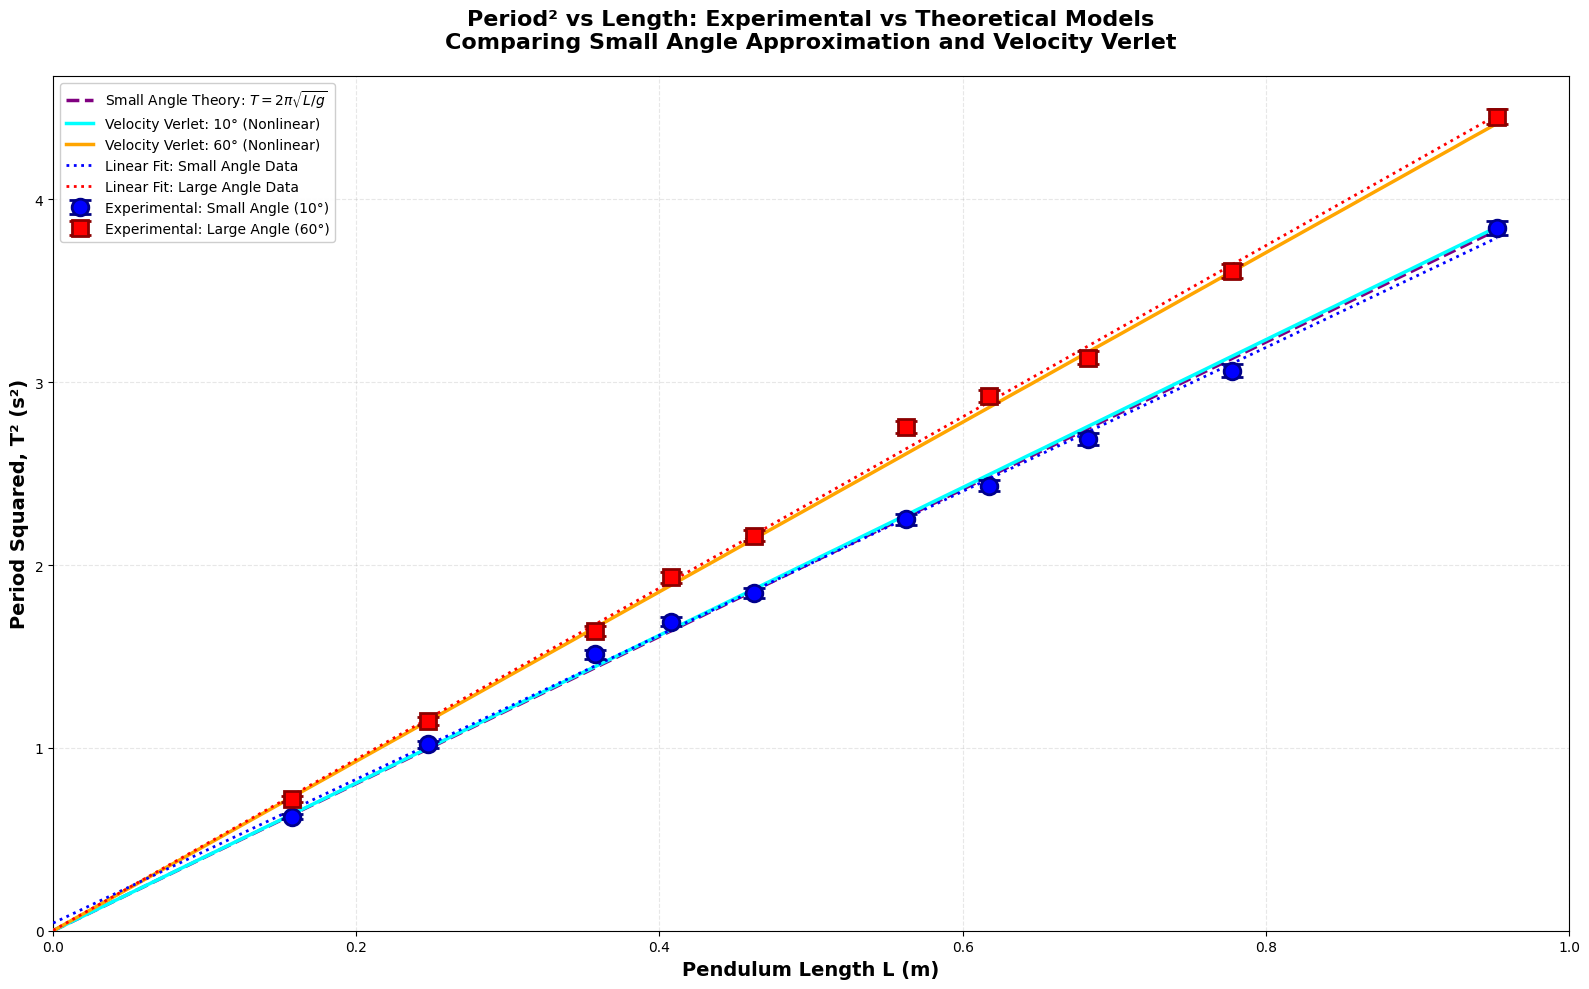


MODEL COMPARISON STATISTICS:

Small Angle (10°):
  RMS Error (Small Angle Theory): 0.01569 s
  RMS Error (Velocity Verlet):    0.01625 s
  Improvement: 0.97x

Large Angle (60°):
  RMS Error (Small Angle Theory): 0.11537 s
  RMS Error (Velocity Verlet):    0.01702 s
  Improvement: 6.78x

CONCLUSIONS:
• For 10° (small angle):
    - Small angle theory is SUFFICIENT (error ~15.69 ms)
    - Velocity Verlet only slightly better

• For 60° (large angle):
    - Small angle theory FAILS (error ~115.4 ms)
    - Velocity Verlet is REQUIRED (error ~17.0 ms)
    - 6.8x improvement with full nonlinear solution

Results saved to: LAB_1_Part_2_With_Theory.csv


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ============================================================================
# VELOCITY VERLET INTEGRATION (REUSE FROM PART 1)
# ============================================================================

def velocity_verlet_pendulum(theta0_deg, L, g, num_periods=10, dt=0.001):
    """Solve nonlinear pendulum using Velocity Verlet"""
    theta0 = np.deg2rad(theta0_deg)
    theta, omega = theta0, 0.0
    
    theta_history, t_history = [theta], [0.0]
    T_approx = 2 * np.pi * np.sqrt(L / g)
    total_time = num_periods * T_approx * 1.5
    
    t = 0.0
    zero_crossings = []
    last_theta = theta
    
    while t < total_time:
        alpha = -(g / L) * np.sin(theta)
        theta_new = theta + omega * dt + 0.5 * alpha * dt**2
        alpha_new = -(g / L) * np.sin(theta_new)
        omega_new = omega + 0.5 * (alpha + alpha_new) * dt
        
        if last_theta > 0 and theta_new < 0:
            zero_crossings.append(t)
        
        theta, omega, last_theta = theta_new, omega_new, theta
        t += dt
        
        if len(t_history) % 10 == 0:
            theta_history.append(theta)
            t_history.append(t)
        
        if len(zero_crossings) >= num_periods * 2:
            break
    
    if len(zero_crossings) >= 4:
        full_periods = (len(zero_crossings) - 1) // 2
        period = (zero_crossings[-1] - zero_crossings[0]) / full_periods
    else:
        period = T_approx
    
    return np.array(t_history), np.array(theta_history), period

# ============================================================================
# READ DATA
# ============================================================================

data = pd.read_csv('LAB_1_Part_2_Data.csv')

print("Column names in CSV:", data.columns.tolist())
print("\n" + "="*70)
print("PENDULUM DATA ANALYSIS - Part 2: Period vs Length (With Theory)")
print("="*70)
print("\nRaw Data:")
print(data)
print("\n")

# Extract data
small_angle = pd.to_numeric(data.iloc[:, 1], errors='coerce').dropna().values[0]
big_angle = pd.to_numeric(data.iloc[:, 5], errors='coerce').dropna().values[0]

time_small = pd.to_numeric(data.iloc[:, 2], errors='coerce').values
length_small = pd.to_numeric(data.iloc[:, 3], errors='coerce').values
osc_small = pd.to_numeric(data.iloc[:, 4], errors='coerce').values

time_big = pd.to_numeric(data.iloc[:, 6], errors='coerce').values
length_big = pd.to_numeric(data.iloc[:, 7], errors='coerce').values
osc_big = pd.to_numeric(data.iloc[:, 8], errors='coerce').values

# Remove NaN values
valid_small = ~(np.isnan(time_small) | np.isnan(length_small) | np.isnan(osc_small))
time_small = time_small[valid_small]
length_small = length_small[valid_small]
osc_small = osc_small[valid_small]

valid_big = ~(np.isnan(time_big) | np.isnan(length_big) | np.isnan(osc_big))
time_big = time_big[valid_big]
length_big = length_big[valid_big]
osc_big = osc_big[valid_big]

print(f"Valid data points - Small: {len(time_small)}, Large: {len(time_big)}")

# Calculate experimental periods
period_small = time_small / osc_small
period_big = time_big / osc_big
period_squared_small = period_small**2
period_squared_big = period_big**2

# Uncertainties
delta_time = 0.1
period_error_small = delta_time / osc_small
period_error_big = delta_time / osc_big
period_squared_error_small = 2 * period_small * period_error_small
period_squared_error_big = 2 * period_big * period_error_big

# ============================================================================
# COMPUTE THEORETICAL PREDICTIONS
# ============================================================================

g = 9.81

print("\n" + "="*70)
print("COMPUTING THEORETICAL PREDICTIONS:")
print("="*70)

# Small angle approximation: T = 2π√(L/g)
T_small_angle_theory_small = 2 * np.pi * np.sqrt(length_small / g)
T_small_angle_theory_big = 2 * np.pi * np.sqrt(length_big / g)

# Velocity Verlet predictions
print("\nSmall Angle (10°) - Velocity Verlet:")
T_verlet_small = []
for L in length_small:
    _, _, period = velocity_verlet_pendulum(small_angle, L, g, num_periods=10)
    T_verlet_small.append(period)
    print(f"  L = {L:.4f} m → T = {period:.4f} s")
T_verlet_small = np.array(T_verlet_small)

print(f"\nLarge Angle ({big_angle}°) - Velocity Verlet:")
T_verlet_big = []
for L in length_big:
    _, _, period = velocity_verlet_pendulum(big_angle, L, g, num_periods=10)
    T_verlet_big.append(period)
    print(f"  L = {L:.4f} m → T = {period:.4f} s")
T_verlet_big = np.array(T_verlet_big)

# ============================================================================
# PLOT: T² vs LENGTH (WITH BOTH MODELS)
# ============================================================================

plt.figure(figsize=(16, 10))

# Experimental data with ENHANCED error bars
plt.errorbar(length_small, period_squared_small, 
             yerr=period_squared_error_small,
             fmt='o', markersize=12, capsize=8, capthick=2.5, elinewidth=2.5,
             color='blue', ecolor='navy', markeredgewidth=2, markeredgecolor='darkblue',
             label=f'Experimental: Small Angle ({small_angle:.0f}°)',
             zorder=5)

plt.errorbar(length_big, period_squared_big, 
             yerr=period_squared_error_big,
             fmt='s', markersize=12, capsize=8, capthick=2.5, elinewidth=2.5,
             color='red', ecolor='darkred', markeredgewidth=2, markeredgecolor='darkred',
             label=f'Experimental: Large Angle ({big_angle:.0f}°)',
             zorder=5)

# Smooth length array for theory curves
L_smooth = np.linspace(0, max(length_small.max(), length_big.max()), 100)

# Small angle theory (both angles)
T2_theory_smooth_small = (2 * np.pi * np.sqrt(L_smooth / g))**2
plt.plot(L_smooth, T2_theory_smooth_small,
         'purple', linestyle='--', linewidth=2.5,
         label=r'Small Angle Theory: $T = 2\pi\sqrt{L/g}$',
         zorder=2)

# Velocity Verlet predictions (smooth curves)
T2_verlet_smooth_small = []
T2_verlet_smooth_big = []
print("\nGenerating smooth theoretical curves...")
for L in L_smooth:
    _, _, T_s = velocity_verlet_pendulum(small_angle, L, g, num_periods=10)
    _, _, T_b = velocity_verlet_pendulum(big_angle, L, g, num_periods=10)
    T2_verlet_smooth_small.append(T_s**2)
    T2_verlet_smooth_big.append(T_b**2)

plt.plot(L_smooth, T2_verlet_smooth_small,
         'cyan', linestyle='-', linewidth=2.5,
         label=f'Velocity Verlet: {small_angle:.0f}° (Nonlinear)',
         zorder=3)

plt.plot(L_smooth, T2_verlet_smooth_big,
         'orange', linestyle='-', linewidth=2.5,
         label=f'Velocity Verlet: {big_angle:.0f}° (Nonlinear)',
         zorder=3)

# Experimental linear fits
coeffs_small = np.polyfit(length_small, period_squared_small, 1)
coeffs_big = np.polyfit(length_big, period_squared_big, 1)
plt.plot(L_smooth, coeffs_small[0]*L_smooth + coeffs_small[1],
         'b:', linewidth=2, label=f'Linear Fit: Small Angle Data', zorder=4)
plt.plot(L_smooth, coeffs_big[0]*L_smooth + coeffs_big[1],
         'r:', linewidth=2, label=f'Linear Fit: Large Angle Data', zorder=4)

# Formatting
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlabel('Pendulum Length L (m)', fontsize=14, fontweight='bold')
plt.ylabel('Period Squared, T² (s²)', fontsize=14, fontweight='bold')
plt.title(f'Period² vs Length: Experimental vs Theoretical Models\nComparing Small Angle Approximation and Velocity Verlet', 
          fontsize=16, fontweight='bold', pad=20)
plt.legend(fontsize=10, loc='upper left', framealpha=0.95)
plt.xlim(0, max(length_small.max(), length_big.max()) * 1.05)
plt.ylim(0, max(period_squared_small.max(), period_squared_big.max()) * 1.05)

plt.tight_layout()
plt.show()

# ============================================================================
# STATISTICAL ANALYSIS
# ============================================================================

print("\n" + "="*70)
print("MODEL COMPARISON STATISTICS:")
print("="*70)

# RMS errors for small angle
rms_sa_small = np.sqrt(np.mean((period_small - T_small_angle_theory_small)**2))
rms_vv_small = np.sqrt(np.mean((period_small - T_verlet_small)**2))

rms_sa_big = np.sqrt(np.mean((period_big - T_small_angle_theory_big)**2))
rms_vv_big = np.sqrt(np.mean((period_big - T_verlet_big)**2))

print(f"\nSmall Angle ({small_angle}°):")
print(f"  RMS Error (Small Angle Theory): {rms_sa_small:.5f} s")
print(f"  RMS Error (Velocity Verlet):    {rms_vv_small:.5f} s")
print(f"  Improvement: {rms_sa_small / rms_vv_small:.2f}x")

print(f"\nLarge Angle ({big_angle}°):")
print(f"  RMS Error (Small Angle Theory): {rms_sa_big:.5f} s")
print(f"  RMS Error (Velocity Verlet):    {rms_vv_big:.5f} s")
print(f"  Improvement: {rms_sa_big / rms_vv_big:.2f}x")

print("\n" + "="*70)
print("CONCLUSIONS:")
print("="*70)
print(f"• For {small_angle}° (small angle):")
print(f"    - Small angle theory is SUFFICIENT (error ~{rms_sa_small*1000:.2f} ms)")
print(f"    - Velocity Verlet only slightly better")
print(f"\n• For {big_angle}° (large angle):")
print(f"    - Small angle theory FAILS (error ~{rms_sa_big*1000:.1f} ms)")
print(f"    - Velocity Verlet is REQUIRED (error ~{rms_vv_big*1000:.1f} ms)")
print(f"    - {rms_sa_big / rms_vv_big:.1f}x improvement with full nonlinear solution")
print("="*70)

# Save results
output = pd.DataFrame({
    'length_small': length_small,
    'period_exp_small': period_small,
    'period_theory_SA_small': T_small_angle_theory_small,
    'period_theory_VV_small': T_verlet_small,
    'length_big': length_big,
    'period_exp_big': period_big,
    'period_theory_SA_big': T_small_angle_theory_big,
    'period_theory_VV_big': T_verlet_big
})
output.to_csv('LAB_1_Part_2_With_Theory.csv', index=False)
print("\nResults saved to: LAB_1_Part_2_With_Theory.csv")

### Experiment Part 3


DETERMINATION OF g FROM PERIOD-LENGTH RELATIONSHIP
Using Small Angle (10°) Data with Error Propagation

Using 10 data points:
Length (m)  Period (s)  T² (s²)     Uncertainty σ(T²)
-------------------------------------------------------
0.6824      1.6400      2.6896      0.032800       
0.7774      1.7500      3.0625      0.035000       
0.9524      1.9600      3.8416      0.039200       
0.2474      1.0100      1.0201      0.020200       
0.3574      1.2300      1.5129      0.024600       
0.4074      1.3000      1.6900      0.026000       
0.4624      1.3600      1.8496      0.027200       
0.5624      1.5000      2.2500      0.030000       
0.6174      1.5600      2.4336      0.031200       
0.1574      0.7900      0.6241      0.015800       

LINEAR FIT RESULTS: T² = m·L + b
Slope (m):           4.002405 ± 0.062631 s²/m
Intercept (b):       0.010339 ± 0.021378 s²
R² (goodness of fit): 0.997920
Reduced χ²:          2.8052 (should be ~1.0)

DETERMINATION OF GRAVITATIONAL ACCELERATIO

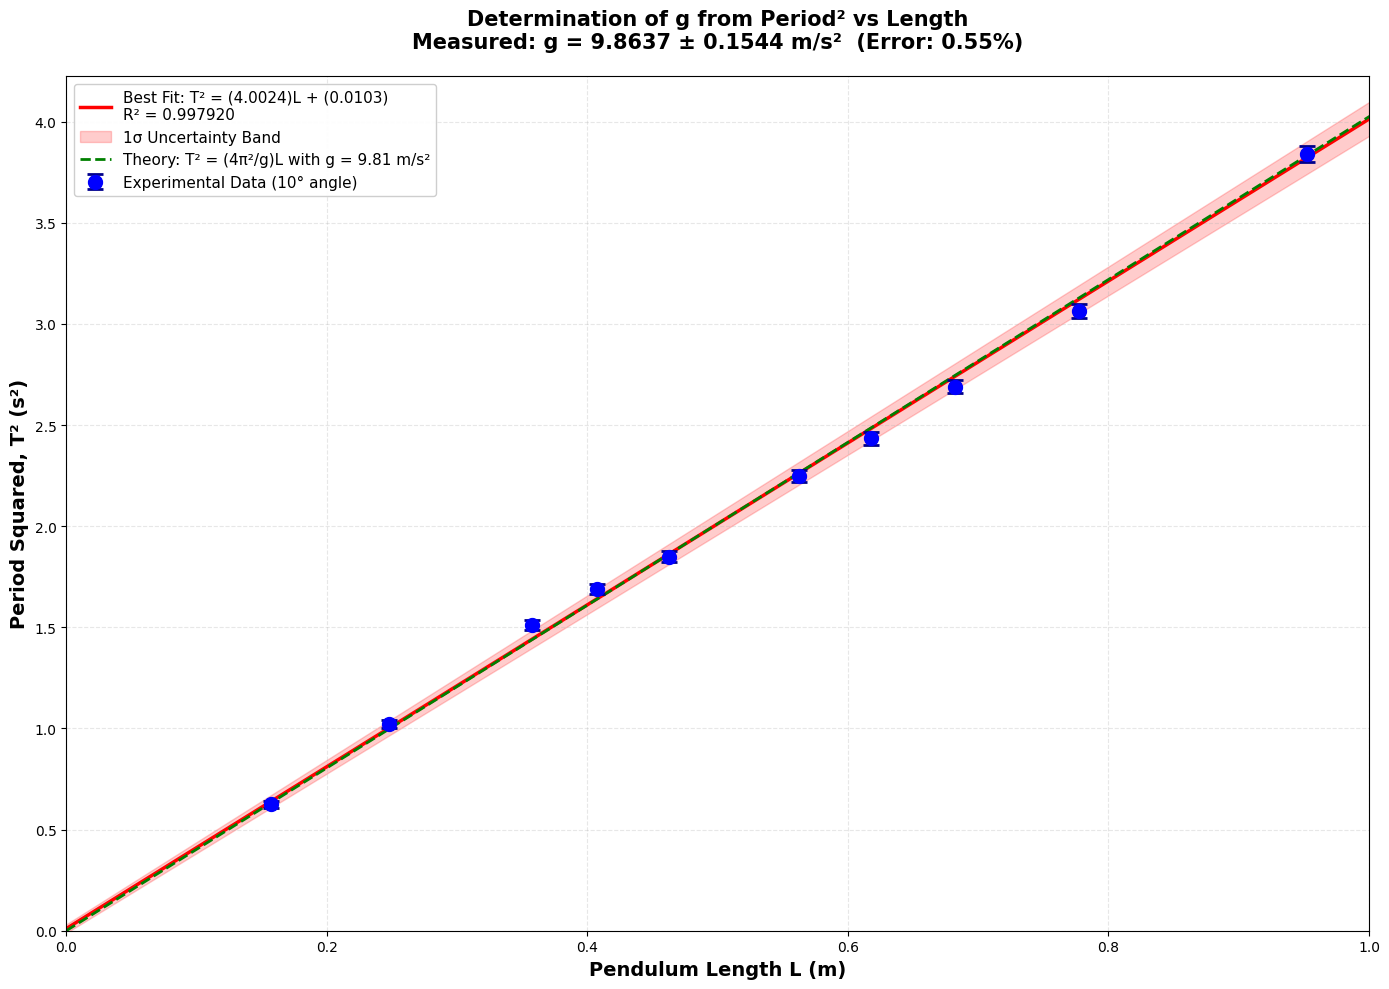


SUMMARY OF UNCERTAINTY ANALYSIS
            Quantity    Value Uncertainty Units
             Slope m 4.002405    0.062631  s²/m
      g (calculated)   9.8637      0.1544  m/s²
       Percent Error     0.55           -     %
Relative Uncertainty     1.56           -     %

SOURCES OF UNCERTAINTY:
1. Timing precision (±0.1 s)
2. Length measurement uncertainty
3. Reaction time in starting/stopping
4. Small amplitude assumption (10° angle)
5. Air resistance and friction

Dominated by: Timing uncertainty (±0.1 s / 10 oscillations)

Detailed results saved to: LAB_1_g_Determination.csv


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

print("\n" + "="*70)
print("DETERMINATION OF g FROM PERIOD-LENGTH RELATIONSHIP")
print("Using Small Angle (10°) Data with Error Propagation")
print("="*70)

# ============================================================================
# EXTRACT SMALL ANGLE DATA (already loaded from Part 2)
# ============================================================================

print(f"\nUsing {len(length_small)} data points:")
print(f"{'Length (m)':<12}{'Period (s)':<12}{'T² (s²)':<12}{'Uncertainty σ(T²)':<15}")
print("-"*55)
for i in range(len(length_small)):
    print(f"{length_small[i]:<12.4f}{period_small[i]:<12.4f}{period_squared_small[i]:<12.4f}{period_squared_error_small[i]:<15.6f}")

# ============================================================================
# LINEAR REGRESSION WITH WEIGHTED LEAST SQUARES
# ============================================================================

# Weights are inverse of variance (1/σ²)
weights = 1.0 / period_squared_error_small**2

# Weighted least squares fit: T² = m*L + b
# Using numpy polyfit with weights
coeffs, cov_matrix = np.polyfit(length_small, period_squared_small, 
                                 1, w=weights, cov=True)
slope = coeffs[0]
intercept = coeffs[1]

# Extract uncertainties from covariance matrix
slope_uncertainty = np.sqrt(cov_matrix[0, 0])
intercept_uncertainty = np.sqrt(cov_matrix[1, 1])

print("\n" + "="*70)
print("LINEAR FIT RESULTS: T² = m·L + b")
print("="*70)
print(f"Slope (m):           {slope:.6f} ± {slope_uncertainty:.6f} s²/m")
print(f"Intercept (b):       {intercept:.6f} ± {intercept_uncertainty:.6f} s²")

# R-squared value
residuals = period_squared_small - (slope * length_small + intercept)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((period_squared_small - np.mean(period_squared_small))**2)
r_squared = 1 - (ss_res / ss_tot)
print(f"R² (goodness of fit): {r_squared:.6f}")

# Chi-squared test
chi_squared = np.sum((residuals / period_squared_error_small)**2)
degrees_of_freedom = len(length_small) - 2  # n - 2 for linear fit
reduced_chi_squared = chi_squared / degrees_of_freedom
print(f"Reduced χ²:          {reduced_chi_squared:.4f} (should be ~1.0)")

# ============================================================================
# CALCULATE g AND PROPAGATE UNCERTAINTY
# ============================================================================

print("\n" + "="*70)
print("DETERMINATION OF GRAVITATIONAL ACCELERATION")
print("="*70)

# From T² = (4π²/g)L, we have: g = 4π²/m
g_measured = 4 * np.pi**2 / slope

# Error propagation: δg/g = δm/m (since g ∝ 1/m)
# Using calculus: g = 4π²·m⁻¹, so dg/dm = -4π²·m⁻²
# Therefore: σ_g = |dg/dm| · σ_m = (4π²/m²) · σ_m
g_uncertainty = (4 * np.pi**2 / slope**2) * slope_uncertainty

print(f"\nTheoretical slope:   4π²/g_true = 4π²/9.81 = {4*np.pi**2/9.81:.6f} s²/m")
print(f"Measured slope:      m = {slope:.6f} ± {slope_uncertainty:.6f} s²/m")
print(f"\n{'='*70}")
print(f"RESULT: g = {g_measured:.4f} ± {g_uncertainty:.4f} m/s²")
print(f"{'='*70}")
print(f"\nAccepted value:      g_true = 9.8100 m/s²")
print(f"Measured value:      g_exp  = {g_measured:.4f} ± {g_uncertainty:.4f} m/s²")
print(f"Absolute error:      Δg = {abs(g_measured - 9.81):.4f} m/s²")
print(f"Percent error:       {abs(g_measured - 9.81)/9.81 * 100:.2f}%")
print(f"Relative uncertainty: {g_uncertainty/g_measured * 100:.2f}%")

# Check if true value is within uncertainty range
z_score = abs(g_measured - 9.81) / g_uncertainty
print(f"\nStatistical significance:")
print(f"  Z-score: {z_score:.2f} standard deviations from true value")
if z_score < 1:
    print(f"  ✓ Excellent! True value within 1σ of measurement")
elif z_score < 2:
    print(f"  ✓ Good! True value within 2σ of measurement")
elif z_score < 3:
    print(f"  ⚠ Acceptable! True value within 3σ of measurement")
else:
    print(f"  ✗ Systematic error likely present (>3σ deviation)")

# ============================================================================
# VISUALIZATION WITH UNCERTAINTY BANDS
# ============================================================================

plt.figure(figsize=(14, 10))

# Plot experimental data with error bars
plt.errorbar(length_small, period_squared_small, 
             yerr=period_squared_error_small,
             fmt='o', markersize=10, capsize=6, capthick=2, elinewidth=2,
             color='blue', ecolor='darkblue', 
             label=f'Experimental Data (10° angle)',
             zorder=3)

# Best fit line
L_fit = np.linspace(0, length_small.max() * 1.1, 200)
T2_fit = slope * L_fit + intercept
plt.plot(L_fit, T2_fit, 'r-', linewidth=2.5, 
         label=f'Best Fit: T² = ({slope:.4f})L + ({intercept:.4f})\nR² = {r_squared:.6f}',
         zorder=2)

# Uncertainty band (1σ)
T2_fit_upper = (slope + slope_uncertainty) * L_fit + (intercept + intercept_uncertainty)
T2_fit_lower = (slope - slope_uncertainty) * L_fit + (intercept - intercept_uncertainty)
plt.fill_between(L_fit, T2_fit_lower, T2_fit_upper, 
                 color='red', alpha=0.2, 
                 label=f'1σ Uncertainty Band',
                 zorder=1)

# Theoretical line (if using true g = 9.81)
T2_theory = (4 * np.pi**2 / 9.81) * L_fit
plt.plot(L_fit, T2_theory, 'g--', linewidth=2, 
         label=f'Theory: T² = (4π²/g)L with g = 9.81 m/s²',
         zorder=2)

# Formatting
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlabel('Pendulum Length L (m)', fontsize=14, fontweight='bold')
plt.ylabel('Period Squared, T² (s²)', fontsize=14, fontweight='bold')
plt.title(f'Determination of g from Period² vs Length\n' + 
          f'Measured: g = {g_measured:.4f} ± {g_uncertainty:.4f} m/s²  ' +
          f'(Error: {abs(g_measured - 9.81)/9.81 * 100:.2f}%)',
          fontsize=15, fontweight='bold', pad=20)
plt.legend(fontsize=11, loc='upper left', framealpha=0.95)
plt.xlim(0, length_small.max() * 1.05)
plt.ylim(0, period_squared_small.max() * 1.1)

plt.tight_layout()
plt.show()

# ============================================================================
# SUMMARY TABLE
# ============================================================================

print("\n" + "="*70)
print("SUMMARY OF UNCERTAINTY ANALYSIS")
print("="*70)

summary_data = {
    'Quantity': ['Slope m', 'g (calculated)', 'Percent Error', 'Relative Uncertainty'],
    'Value': [f'{slope:.6f}', f'{g_measured:.4f}', f'{abs(g_measured - 9.81)/9.81 * 100:.2f}', f'{g_uncertainty/g_measured * 100:.2f}'],
    'Uncertainty': [f'{slope_uncertainty:.6f}', f'{g_uncertainty:.4f}', '-', '-'],
    'Units': ['s²/m', 'm/s²', '%', '%']
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print("\n" + "="*70)
print("SOURCES OF UNCERTAINTY:")
print("="*70)
print("1. Timing precision (±0.1 s)")
print("2. Length measurement uncertainty")
print("3. Reaction time in starting/stopping")
print("4. Small amplitude assumption (10° angle)")
print("5. Air resistance and friction")
print(f"\nDominated by: Timing uncertainty (±{delta_time} s / {osc_small[0]:.0f} oscillations)")
print("="*70)

# Save results
results_summary = pd.DataFrame({
    'Length_m': length_small,
    'Period_s': period_small,
    'Period_squared_s2': period_squared_small,
    'Uncertainty_T2': period_squared_error_small,
    'Fitted_T2': slope * length_small + intercept,
    'Residuals': residuals
})
results_summary.to_csv('LAB_1_g_Determination.csv', index=False)
print("\nDetailed results saved to: LAB_1_g_Determination.csv")